# Image Classifier 

## 1. Import important libraries

In [41]:
import numpy as np
import pandas as pd
import cv2
import pywt
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline 

In [2]:
face_cascade = cv2.CascadeClassifier('D:\Akash\ML Project\project-2\haarcascades\haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('D:\Akash\ML Project\project-2\haarcascades\haarcascade_eye.xml')

## 2. function to get cropped image

In [3]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x,y,w,h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >= 2:
            return roi_color

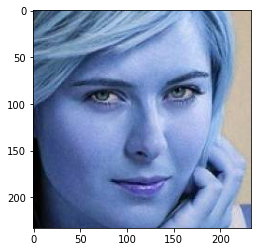

In [4]:
cropped_image = get_cropped_image_if_2_eyes('D:\Akash\ML Project\project-2\images_dataset\maria_sharapova\sharapova-hits-the-practice-courts-and-met-ball-kids.jpg')

plt.imshow(cropped_image)

## 4. create a folder having all cropped image

In [5]:
path_to_data = "./images_dataset/"
path_to_crop_data = "./images_dataset/cropped/"

In [6]:
import os
img_dirs = []
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dirs.append(entry.path)

img_dirs

['./images_dataset/cropped',
 './images_dataset/lionel_messi',
 './images_dataset/maria_sharapova',
 './images_dataset/roger_federer',
 './images_dataset/serena_williams',
 './images_dataset/virat_kohli']

In [7]:
import shutil
if os.path.exists(path_to_crop_data):  # if this folder exist then it automatically deleted.
    shutil.rmtree(path_to_crop_data)

os.mkdir(path_to_crop_data)   # it created the folder named cropped

## 5. crop all pics and store them in a cropped folder

In [8]:
cropped_image_dirs = []
celebrity_file_names_dict = {}

for img_dir in img_dirs:
    count = 1
    celebrity_name = img_dir.split('/')[-1]
    celebrity_file_names_dict[celebrity_name] = []

    for image in os.scandir(img_dir):
        roi_color = get_cropped_image_if_2_eyes(image.path)
        if roi_color is not None:
            cropped_folder_path = path_to_crop_data + celebrity_name
            if not os.path.exists(cropped_folder_path):
                os.makedirs(cropped_folder_path)
                cropped_image_dirs.append(cropped_folder_path)
                print("Generating cropped images in folder: ",cropped_folder_path)

            cropped_image_name = celebrity_name + str(count) + ".png"
            cropped_image_path = cropped_folder_path + "/" + cropped_image_name

            cv2.imwrite(cropped_image_path, roi_color)  # save image in this path
            
            celebrity_file_names_dict[celebrity_name].append(cropped_image_path)
            count += 1


Generating cropped images in folder:  ./images_dataset/cropped/lionel_messi
Generating cropped images in folder:  ./images_dataset/cropped/maria_sharapova
Generating cropped images in folder:  ./images_dataset/cropped/roger_federer
Generating cropped images in folder:  ./images_dataset/cropped/serena_williams
Generating cropped images in folder:  ./images_dataset/cropped/virat_kohli


## 6. Manually examine cropped folder and delete any unwanted images

In [27]:
celebrity_file_names_dict = {}
for img_dir in cropped_image_dirs:
    celebrity_name = img_dir.split('/')[-1]
    file_list = []
    for entry in os.scandir(img_dir):
        file_list.append(entry.path)
    celebrity_file_names_dict[celebrity_name] = file_list
    
celebrity_file_names_dict['lionel_messi'][:10]

['./images_dataset/cropped/lionel_messi\\lionel_messi1.png',
 './images_dataset/cropped/lionel_messi\\lionel_messi10.png',
 './images_dataset/cropped/lionel_messi\\lionel_messi11.png',
 './images_dataset/cropped/lionel_messi\\lionel_messi13.png',
 './images_dataset/cropped/lionel_messi\\lionel_messi14.png',
 './images_dataset/cropped/lionel_messi\\lionel_messi15.png',
 './images_dataset/cropped/lionel_messi\\lionel_messi16.png',
 './images_dataset/cropped/lionel_messi\\lionel_messi17.png',
 './images_dataset/cropped/lionel_messi\\lionel_messi18.png',
 './images_dataset/cropped/lionel_messi\\lionel_messi19.png']

## 7. Wavelet Transform

In [28]:
def w2d(img, mode='haar', level=1):
    imArray = img
    #Datatype conversions
    #convert to grayscale
    imArray = cv2.cvtColor( imArray,cv2.COLOR_RGB2GRAY )
    #convert to float
    imArray =  np.float32(imArray)   
    imArray /= 255
    # compute coefficients 
    coeffs=pywt.wavedec2(imArray, mode, level=level)

    #Process Coefficients
    coeffs_H=list(coeffs)  
    coeffs_H[0] *= 0;  

    # reconstruction
    imArray_H=pywt.waverec2(coeffs_H, mode)
    imArray_H *= 255
    imArray_H =  np.uint8(imArray_H)

    return imArray_H

## 8. Assign Celebrity name a number

In [29]:
class_dict = {}
count = 0
for celebrity_name in celebrity_file_names_dict.keys():
    class_dict[celebrity_name] = count
    count = count + 1

class_dict

{'lionel_messi': 0,
 'maria_sharapova': 1,
 'roger_federer': 2,
 'serena_williams': 3,
 'virat_kohli': 4}

## 9. Assign a X an Y parameter

In [30]:
x,y = [],[]

for celebrity_name , training_files in celebrity_file_names_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)
        if img is None:
            continue
        scalled_raw_img = cv2.resize(img , (32,32))
        img_har = w2d(img ,'db1',5) # wavelet transform of image
        scalled_img_har = cv2.resize(img_har ,(32,32))

        combined_image = np.vstack((scalled_raw_img.reshape(32*32*3,1),scalled_img_har.reshape(32*32,1)))

        x.append(combined_image)
        y.append(class_dict[celebrity_name])

In [36]:
x = np.array(x).reshape(len(x),4096).astype(float)
x.shape

(164, 4096)

## 10. Train Test Splitting

In [42]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)

## 11. Let's use GridSearch 
### Goal is to come up with best model with best fine tuned parameters

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

In [44]:
model_params = {
    'svm': {
        'model': svm.SVC(gamma='auto',probability=True),
        'params' : {
            'svc__C': [1,10,100,1000],
            'svc__kernel': ['rbf','linear']
        }  
    },
    'random_forest': {
        'model': RandomForestClassifier(),
        'params' : {
            'randomforestclassifier__n_estimators': [1,5,10]
        }
    },
    'logistic_regression' : {
        'model': LogisticRegression(solver='liblinear',multi_class='auto'),
        'params': {
            'logisticregression__C': [1,5,10]
        }
    }
}

In [54]:
scores = []
best_estimators = {}
import pandas as pd
for algo, mp in model_params.items():
    pipe = make_pipeline(StandardScaler(), mp['model'])
    clf =  GridSearchCV(pipe, mp['params'], cv=5, return_train_score=False)
    clf.fit(x_train, y_train)
    scores.append({
        'model': algo,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
    best_estimators[algo] = clf.best_estimator_
    
df = pd.DataFrame(scores,columns=['model','best_score','best_params'])
df

,model,best_score,best_params
0,svm,0.845667,"{'svc__C': 1, 'svc__kernel': 'linear'}"
1,random_forest,0.650333,{'randomforestclassifier__n_estimators': 10}
2,logistic_regression,0.870000,{'logisticregression__C': 5}


## 12. Now We try our test data in best model

In [48]:
best_estimators['svm'].score(x_test,y_test)

0.9512195121951219

In [57]:
best_estimators['random_forest'].score(x_test,y_test)

0.7560975609756098

In [58]:
best_estimators['logistic_regression'].score(x_test,y_test)

0.975609756097561

## 13. Choose best model as our classifier

In [60]:
best_clf = best_estimators['logistic_regression']

In [67]:
best_clf.predict(x[[40]])

array([1])

## 14. plot a confusion matrix

Text(69.0, 0.5, 'Truth')

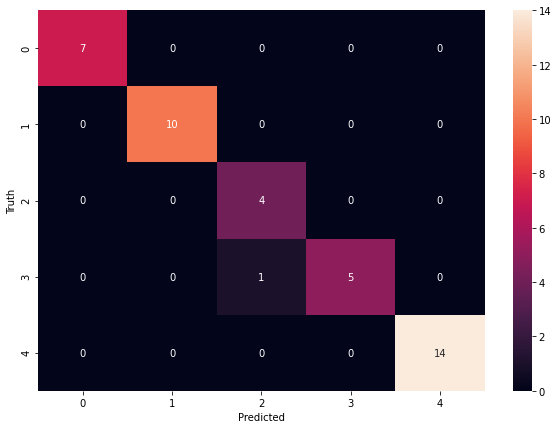

In [62]:
from sklearn.metrics import confusion_matrix
import seaborn as sn

cm = confusion_matrix(y_test, best_clf.predict(x_test))
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [63]:
class_dict

{'lionel_messi': 0,
 'maria_sharapova': 1,
 'roger_federer': 2,
 'serena_williams': 3,
 'virat_kohli': 4}

## 15. Save the trained model

In [64]:
import joblib 
# Save the model as a pickle in a file 
joblib.dump(best_clf, 'saved_model.pkl')

['saved_model.pkl']